In [2]:
from pathlib import Path

matcad_path = Path(
    r"C:\Users\deqin\Downloads\matcad2022_de-be_bfp_mps1.gpkg"
)

print("Exists:", matcad_path.exists())
print("File size (GB):", round(matcad_path.stat().st_size / (1024**3), 2))

Exists: True
File size (GB): 0.66


In [5]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

print("Libraries loaded.")

Libraries loaded.


In [3]:
import pyogrio

pyogrio.list_layers(matcad_path)

array([['Mat1', 'MultiPolygon'],
       ['Gwp1', 'MultiPolygon']], dtype=object)

In [6]:
matcad = gpd.read_file(
    matcad_path,
    layer="Mat1"
)

print("Shape:", matcad.shape)
print("CRS:", matcad.crs)
print("Columns:", len(matcad.columns))

matcad.head()

Shape: (534612, 54)
CRS: EPSG:25833
Columns: 54


,bldg_gmlid,AGS,bldg_area,bldg_volume,bldg_function,BtySetID,BtyID,BtySig,Mat_Sum,Mat_ConNrm,...,Mat_HcbRcv,Mat_BtmRcv,Mat_BtmMem,Mat_FemRcv,Mat_FemOth,Mat_NfeAlm,Mat_NfeAlu,Mat_NfeCpr,Mat_NfeOth,geometry
0,DEBE00YY2j2001H8,11000000,60.35,407.90,31001_1010,4.0,247,SFH,210.095,79.397,...,0.268,0.083,0.0,0.000,8.169,0.0,0.026,0.000,0.000,"MULTIPOLYGON (((372623.288 5805973.392, 372619..."
1,DEBE00YY2j3001Je,11000000,226.43,2207.59,31001_3024,4.0,161,ONR,1078.961,565.637,...,0.235,0.341,0.0,0.000,60.157,0.0,1.344,0.036,0.715,"MULTIPOLYGON (((372777.724 5808212.359, 372787..."
2,DEBE00YYSV00004C,11000000,164.34,1500.49,31001_1010,4.0,246,MFH,697.302,304.191,...,0.632,0.873,0.0,0.044,34.679,0.0,0.000,0.000,0.000,"MULTIPOLYGON (((372612.792 5806240.198, 372614..."
3,DEBE00YYSV00004D,11000000,17.05,40.61,31001_1313,4.0,159,NAS,33.111,22.562,...,0.004,0.041,0.0,0.000,2.180,0.0,0.002,0.000,0.000,"MULTIPOLYGON (((372587.268 5806231.177, 372587..."
4,DEBE00YYSV00004J,11000000,11.01,0.41,31001_1313,4.0,159,NAS,0.334,0.228,...,0.000,0.000,0.0,0.000,0.022,0.0,0.000,0.000,0.000,"MULTIPOLYGON (((372590.378 5806226.277, 372590..."


In [8]:
matcad_osm = matcad[
    [
        "bldg_gmlid",
        "bldg_area",
        "bldg_volume",
        "BtySig",
        "geometry"
    ]
].copy()

print("Shape:", matcad_osm.shape)
print(matcad_osm.head())

Shape: (534612, 5)
         bldg_gmlid  bldg_area  bldg_volume BtySig  \
0  DEBE00YY2j2001H8      60.35       407.90    SFH   
1  DEBE00YY2j3001Je     226.43      2207.59    ONR   
2  DEBE00YYSV00004C     164.34      1500.49    MFH   
3  DEBE00YYSV00004D      17.05        40.61    NAS   
4  DEBE00YYSV00004J      11.01         0.41    NAS   

                                            geometry  
0  MULTIPOLYGON (((372623.288 5805973.392, 372619...  
1  MULTIPOLYGON (((372777.724 5808212.359, 372787...  
2  MULTIPOLYGON (((372612.792 5806240.198, 372614...  
3  MULTIPOLYGON (((372587.268 5806231.177, 372587...  
4  MULTIPOLYGON (((372590.378 5806226.277, 372590...  


In [9]:
print("CRS:", matcad_osm.crs)
print("Invalid geometries:", (~matcad_osm.geometry.is_valid).sum())
print("Empty geometries:", matcad_osm.geometry.is_empty.sum())
print("Total bounds:", matcad_osm.total_bounds)

CRS: EPSG:25833
Invalid geometries: 309
Empty geometries: 0
Total bounds: [ 370288.326 5799689.728  415635.451 5835888.677]


In [10]:
matcad_wgs84 = matcad_osm.to_crs("EPSG:4326")

minx, miny, maxx, maxy = matcad_wgs84.total_bounds

bbox = f"{minx},{miny},{maxx},{maxy}"

print("OSM bbox:")
print(bbox)

OSM bbox:
13.092786740131386,52.33976284649115,13.758936986334408,52.66049727124638


In [11]:
import requests

test_bbox = "13.35,52.48,13.45,52.55"

url = "https://api.ohsome.org/v1/elements/geometry"

params = {
    "bboxes": test_bbox,
    "time": "2021-01-01",
    "filter": "building=* and building!=no and geometry:polygon",
    "format": "geojson"
}

response = requests.get(url, params=params, timeout=120)

print("Status:", response.status_code)
print("Response size (MB):", round(len(response.content) / 1024 / 1024, 2))
print(response.text[:300])

Status: 403
Response size (MB): 0.0
<!DOCTYPE HTML PUBLIC "-//IETF//DTD HTML 2.0//EN">
<html><head>
<title>403 Forbidden</title>
</head><body>
<h1>Forbidden</h1>
<p>You don't have permission to access this resource.</p>
<hr>
<address>Apache/2.4.58 (Ubuntu) Server at api.ohsome.org Port 443</address>
</body></html>



In [12]:
headers = {
    "Authorization": "eyJvcmciOiI1YjNjZTM1OTc4NTExMTAwMDFjZjYyNDgiLCJpZCI6IjAxOTdmZmNhMWNhNDRkMTNhMTA3NzY4ZmVmM2RmZDFiIiwiaCI6Im11cm11cjY0In0=
    "
}

In [13]:
payload = {
    "aoi": [minx, miny, maxx, maxy],
    "filter": "building=* and geometry:polygon",
    "time": {
        "start": "2021-01-01T00:00:00Z",
        "end": "2021-01-01T00:00:00Z"
    }
}

In [14]:
import requests
from io import BytesIO
import geopandas as gpd

OHSOME_URL = "https://api.heigit.org/ohsome-api/v2-rc"
OHSOME_API_KEY = "PASTE_YOUR_KEY_HERE"

test_bbox = [13.35, 52.48, 13.45, 52.55]

response = requests.post(
    OHSOME_URL + "/extraction/features.parquet",
    json={
        "aoi": test_bbox,
        "filter": "building=* and geometry:polygon",
        "time": "2021-01-01",
    },
    headers={"Authorization": OHSOME_API_KEY},
    timeout=300
)

print("Status:", response.status_code)
print("Response size (MB):", round(len(response.content) / 1024 / 1024, 2))
print(response.text[:300] if response.status_code != 200 else "Successful")

Status: 403
Response size (MB): 0.0
{
    "error": "Access to this API has been disallowed"
}


In [15]:
import requests
from io import BytesIO
import geopandas as gpd

OHSOME_API_KEY = "eyJvcmciOiI1YjNjZTM1OTc4NTExMTAwMDFjZjYyNDgiLCJpZCI6IjAxOTdmZmNhMWNhNDRkMTNhMTA3NzY4ZmVmM2RmZDFiIiwiaCI6Im11cm11cjY0In0=".strip()

OHSOME_URL = "https://api.heigit.org/ohsome-api/v2-rc"

test_bbox = [13.35, 52.48, 13.45, 52.55]

payload = {
    "aoi": test_bbox,
    "filter": "building=* and geometry:polygon",
    "time": "2021-01-01",
    "clip": True
}

response = requests.post(
    OHSOME_URL + "/extraction/features.parquet",
    json=payload,
    headers={
        "authorization": OHSOME_API_KEY,
        "Content-Type": "application/json"
    },
    timeout=300
)

print("Status:", response.status_code)
print("Content-Type:", response.headers.get("content-type"))
print("Response size:", len(response.content))
print(response.text[:500] if response.status_code != 200 else "SUCCESS")

Status: 200
Content-Type: application/vnd.apache.parquet
Response size: 7796903
SUCCESS


In [16]:
osm_test_2021 = gpd.read_parquet(
    BytesIO(response.content)
)

print("Shape:", osm_test_2021.shape)
print("CRS:", osm_test_2021.crs)
print("Columns:", osm_test_2021.columns.tolist())

osm_test_2021.head()

Shape: (33363, 14)
CRS: {"$schema": "https://proj.org/schemas/v0.7/projjson.schema.json", "type": "GeographicCRS", "name": "WGS 84", "datum_ensemble": {"name": "World Geodetic System 1984 ensemble", "members": [{"name": "World Geodetic System 1984 (Transit)"}, {"name": "World Geodetic System 1984 (G730)"}, {"name": "World Geodetic System 1984 (G873)"}, {"name": "World Geodetic System 1984 (G1150)"}, {"name": "World Geodetic System 1984 (G1674)"}, {"name": "World Geodetic System 1984 (G1762)"}, {"name": "World Geodetic System 1984 (G2139)"}, {"name": "World Geodetic System 1984 (G2296)"}], "ellipsoid": {"name": "WGS 84", "semi_major_axis": 6378137, "inverse_flattening": 298.257223563}, "accuracy": "2.0", "id": {"authority": "EPSG", "code": 6326}}, "coordinate_system": {"subtype": "ellipsoidal", "axis": [{"name": "Geodetic latitude", "abbreviation": "Lat", "direction": "north", "unit": "degree"}, {"name": "Geodetic longitude", "abbreviation": "Lon", "direction": "east", "unit": "degree"}

,osm_type,osm_id,edit_timestamp,valid_to_timestamp,version,minor_version,edits,user_id,user_name,changeset_id,tags,geom_type,geom,clipped
0,way,397790877,2020-11-09 22:06:01+00:00,2222-01-01 00:00:00+00:00,3,0,4,418040,Supaplex030,93822089,"[(building, apartments), (building:levels, 4)]",Polygon,"POLYGON ((13.41819 52.48741, 13.41822 52.48741...",False
1,way,378270227,2015-11-04 08:44:52+00:00,2222-01-01 00:00:00+00:00,1,0,1,881429,atpl_pilot,35073414,"[(building, apartments), (building:levels, 5)]",Polygon,"POLYGON ((13.4181 52.49083, 13.41823 52.49079,...",False
2,way,240803989,2015-11-04 08:44:56+00:00,2222-01-01 00:00:00+00:00,4,0,4,881429,atpl_pilot,35073414,"[(building, apartments), (building:levels, 6)]",Polygon,"POLYGON ((13.41958 52.4905, 13.4196 52.4905, 1...",False
3,way,240778128,2020-11-05 23:17:18+00:00,2222-01-01 00:00:00+00:00,5,0,5,418040,Supaplex030,93628270,"[(building, school), (roof:levels, 1), (buildi...",Polygon,"POLYGON ((13.42123 52.49081, 13.42128 52.4908,...",False
4,way,240778132,2020-11-05 23:17:18+00:00,2222-01-01 00:00:00+00:00,4,0,4,418040,Supaplex030,93628270,"[(building, yes), (building:levels, 4)]",Polygon,"POLYGON ((13.42117 52.4904, 13.42123 52.49038,...",False


In [17]:
print(osm_test_2021.geom_type.value_counts())
print(osm_test_2021.total_bounds)

Polygon               32651
MultiPolygon            711
GeometryCollection        1
Name: count, dtype: int64
[13.35 52.48 13.45 52.55]


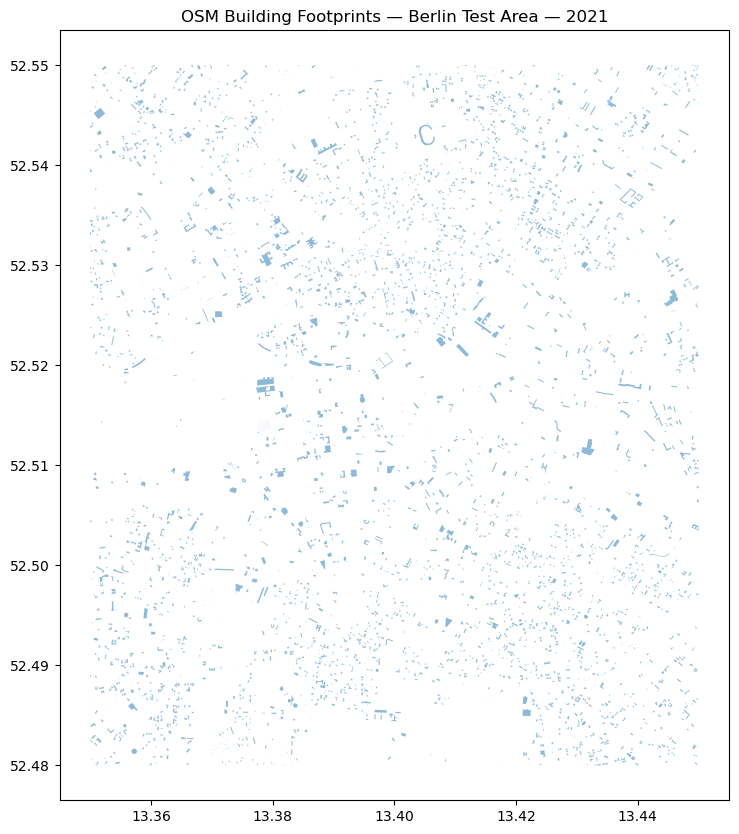

In [18]:
ax = osm_test_2021.sample(
    min(5000, len(osm_test_2021)),
    random_state=42
).plot(figsize=(10, 10), alpha=0.5)

ax.set_title("OSM Building Footprints — Berlin Test Area — 2021")
plt.show()

In [19]:
osm_test_2021 = osm_test_2021.rename(
    columns={"geom": "geometry"}
)

osm_test_2021 = gpd.GeoDataFrame(
    osm_test_2021,
    geometry="geometry",
    crs="EPSG:4326"
)

print(osm_test_2021.geometry.geom_type.value_counts())
print(osm_test_2021.total_bounds)

Polygon               32651
MultiPolygon            711
GeometryCollection        1
Name: count, dtype: int64
[13.35 52.48 13.45 52.55]


In [23]:
print(
    osm_test_2021[
        ["osm_id", "edit_timestamp", "valid_to_timestamp", "version"]
    ].head(20)
)

       osm_id            edit_timestamp        valid_to_timestamp  version
0   397790877 2020-11-09 22:06:01+00:00 2222-01-01 00:00:00+00:00        3
1   378270227 2015-11-04 08:44:52+00:00 2222-01-01 00:00:00+00:00        1
2   240803989 2015-11-04 08:44:56+00:00 2222-01-01 00:00:00+00:00        4
3   240778128 2020-11-05 23:17:18+00:00 2222-01-01 00:00:00+00:00        5
4   240778132 2020-11-05 23:17:18+00:00 2222-01-01 00:00:00+00:00        4
5   342996341 2020-02-29 13:41:41+00:00 2222-01-01 00:00:00+00:00        2
6   240861692 2020-11-05 20:55:51+00:00 2222-01-01 00:00:00+00:00        4
7    85614495 2020-10-06 14:13:32+00:00 2222-01-01 00:00:00+00:00        4
8    37739150 2020-11-17 07:47:30+00:00 2222-01-01 00:00:00+00:00        5
9    85511251 2018-09-04 15:05:04+00:00 2222-01-01 00:00:00+00:00        8
10  543143163 2017-11-27 17:24:13+00:00 2222-01-01 00:00:00+00:00        1
11  342996363 2015-05-05 15:06:09+00:00 2222-01-01 00:00:00+00:00        1
12  342996156 2015-05-05 

In [24]:
print("Requesting full Berlin OSM 2021 building dataset...")

response_2021 = requests.post(
    OHSOME_URL + "/extraction/features.parquet",
    json={
        "aoi": [minx, miny, maxx, maxy],
        "filter": "building=* and building!=no and geometry:polygon",
        "time": "2021-01-01",
        "clip": True
    },
    headers={
        "authorization": OHSOME_API_KEY,
        "Content-Type": "application/json"
    },
    timeout=1800
)

print("Status:", response_2021.status_code)
print("Size (MB):", round(len(response_2021.content) / 1024 / 1024, 2))

Requesting full Berlin OSM 2021 building dataset...
Status: 200
Size (MB): 103.08


In [26]:
print("Status:", response_2021.status_code)
print("Content-Type:", response_2021.headers.get("content-type"))
print("Content-Encoding:", response_2021.headers.get("content-encoding"))
print("First 20 bytes:", response_2021.content[:20])

Status: 200
Content-Type: application/vnd.apache.parquet
Content-Encoding: None
First 20 bytes: b'PAR1\x15\x04\x15&\x158L\x15\x04\x15\x00\x12\x00\x00(\xb5'


In [28]:
print("First 100 bytes:")
print(response_2021.content[:100])

print("\nLast 20 bytes:")
print(response_2021.content[-20:])

First 100 bytes:
b'PAR1\x15\x04\x15&\x158L\x15\x04\x15\x00\x12\x00\x00(\xb5/\xfd \x13\x99\x00\x00\x03\x00\x00\x00way\x08\x00\x00\x00relation\x15\x00\x15\x8e\x01\x15\x98\x01,\x15\xa0\x9c\x01\x15\x10\x15\x06\x15\x06\x1c6\x00(\x03way\x18\x08relation\x11\x11\x00\x00\x00(\xb5/\xfd G\x1d\x02\x00r\xc4\x0f'

Last 20 bytes:
b'+\x96\xb4L\x08\x06g1Bt\x83\x0e<\xbe\xb1d\xdb\x1e\x91t'


In [30]:
content = response_2021.content

print("Total bytes:", len(content))
print("First 4 bytes:", content[:4])
print("Last 4 bytes:", content[-4:])
print("Last 20 bytes:", content[-20:])

Total bytes: 108083184
First 4 bytes: b'PAR1'
Last 4 bytes: b'\xdb\x1e\x91t'
Last 20 bytes: b'+\x96\xb4L\x08\x06g1Bt\x83\x0e<\xbe\xb1d\xdb\x1e\x91t'


In [31]:
from pathlib import Path
import numpy as np
import pandas as pd

output_dir = Path("osm_extractions")
output_dir.mkdir(exist_ok=True)

xs = np.linspace(minx, maxx, 3)  # 2 columns
ys = np.linspace(miny, maxy, 3)  # 2 rows

tiles = []

for i in range(2):
    for j in range(2):
        tile = [
            xs[i],
            ys[j],
            xs[i+1],
            ys[j+1]
        ]
        tiles.append(tile)

tiles

[[13.092786740131386,
  52.33976284649115,
  13.425861863232896,
  52.50013005886876],
 [13.092786740131386,
  52.50013005886876,
  13.425861863232896,
  52.66049727124638],
 [13.425861863232896,
  52.33976284649115,
  13.758936986334408,
  52.50013005886876],
 [13.425861863232896,
  52.50013005886876,
  13.758936986334408,
  52.66049727124638]]

In [32]:
from io import BytesIO
import requests
import pyarrow.parquet as pq

tile_bbox = tiles[0]

response_tile = requests.post(
    OHSOME_URL + "/extraction/features.parquet",
    json={
        "aoi": tile_bbox,
        "filter": "building=* and building!=no and geometry:polygon",
        "time": "2021-01-01",
        "clip": True
    },
    headers={
        "authorization": OHSOME_API_KEY,
        "Content-Type": "application/json"
    },
    timeout=900
)

print("Status:", response_tile.status_code)
print("Size MB:", len(response_tile.content) / 1024**2)
print("First 4:", response_tile.content[:4])
print("Last 4:", response_tile.content[-4:])

Status: 200
Size MB: 30.369794845581055
First 4: b'PAR1'
Last 4: b'PAR1'


In [33]:
osm_tile = gpd.read_parquet(BytesIO(response_tile.content))

print(osm_tile.shape)
print(osm_tile.columns)

(180243, 14)
Index(['osm_type', 'osm_id', 'edit_timestamp', 'valid_to_timestamp', 'version',
       'minor_version', 'edits', 'user_id', 'user_name', 'changeset_id',
       'tags', 'geom_type', 'geom', 'clipped'],
      dtype='object')


In [34]:
from io import BytesIO
from pathlib import Path
import requests
import geopandas as gpd
import time

osm_2021_tiles = []

for idx, tile_bbox in enumerate(tiles):

    print(f"\nDownloading tile {idx+1}/{len(tiles)}")
    print("BBox:", tile_bbox)

    response = requests.post(
        OHSOME_URL + "/extraction/features.parquet",
        json={
            "aoi": tile_bbox,
            "filter": "building=* and building!=no and geometry:polygon",
            "time": "2021-01-01",
            "clip": True
        },
        headers={
            "authorization": OHSOME_API_KEY,
            "Content-Type": "application/json"
        },
        timeout=900
    )

    response.raise_for_status()

    content = response.content

    print("Size MB:", round(len(content) / 1024**2, 2))
    print("Header:", content[:4])
    print("Footer:", content[-4:])

    if content[:4] != b"PAR1" or content[-4:] != b"PAR1":
        raise ValueError(f"Tile {idx+1} is not a valid complete Parquet file")

    tile_gdf = gpd.read_parquet(BytesIO(content))

    print("Buildings:", len(tile_gdf))

    osm_2021_tiles.append(tile_gdf)

    time.sleep(2)


BBox: [13.092786740131386, 52.33976284649115, 13.425861863232896, 52.50013005886876]
Size MB: 30.38
Header: b'PAR1'
Footer: b'PAR1'
Buildings: 180243

BBox: [13.092786740131386, 52.50013005886876, 13.425861863232896, 52.66049727124638]
Size MB: 30.25
Header: b'PAR1'
Footer: b'PAR1'
Buildings: 180559

BBox: [13.425861863232896, 52.33976284649115, 13.758936986334408, 52.50013005886876]
Size MB: 21.65
Header: b'PAR1'
Footer: b'PAR1'
Buildings: 144081

BBox: [13.425861863232896, 52.50013005886876, 13.758936986334408, 52.66049727124638]
Size MB: 19.43
Header: b'PAR1'
Footer: b'PAR1'
Buildings: 128176


In [35]:
osm_2021 = gpd.GeoDataFrame(
    pd.concat(osm_2021_tiles, ignore_index=True),
    geometry="geom",
    crs=osm_2021_tiles[0].crs
)

print("Combined shape:", osm_2021.shape)
print("CRS:", osm_2021.crs)

Combined shape: (633059, 14)
CRS: {"$schema": "https://proj.org/schemas/v0.7/projjson.schema.json", "type": "GeographicCRS", "name": "WGS 84", "datum_ensemble": {"name": "World Geodetic System 1984 ensemble", "members": [{"name": "World Geodetic System 1984 (Transit)"}, {"name": "World Geodetic System 1984 (G730)"}, {"name": "World Geodetic System 1984 (G873)"}, {"name": "World Geodetic System 1984 (G1150)"}, {"name": "World Geodetic System 1984 (G1674)"}, {"name": "World Geodetic System 1984 (G1762)"}, {"name": "World Geodetic System 1984 (G2139)"}, {"name": "World Geodetic System 1984 (G2296)"}], "ellipsoid": {"name": "WGS 84", "semi_major_axis": 6378137, "inverse_flattening": 298.257223563}, "accuracy": "2.0", "id": {"authority": "EPSG", "code": 6326}}, "coordinate_system": {"subtype": "ellipsoidal", "axis": [{"name": "Geodetic latitude", "abbreviation": "Lat", "direction": "north", "unit": "degree"}, {"name": "Geodetic longitude", "abbreviation": "Lon", "direction": "east", "unit":

In [36]:
osm_2021 = osm_2021.rename(columns={"geom": "geometry"})
osm_2021 = gpd.GeoDataFrame(
    osm_2021,
    geometry="geometry",
    crs="EPSG:4326"
)

print(osm_2021.shape)
osm_2021.head()

(633059, 14)


,osm_type,osm_id,edit_timestamp,valid_to_timestamp,version,minor_version,edits,user_id,user_name,changeset_id,tags,geom_type,geometry,clipped
0,way,200902863,2013-01-13 11:02:43+00:00,2222-01-01 00:00:00+00:00,1,0,1,6669,Elwood,14632369,"[(building, yes)]",Polygon,"POLYGON ((13.41233 52.43635, 13.41248 52.43637...",False
1,way,200902893,2014-06-02 16:11:50+00:00,2222-01-01 00:00:00+00:00,2,0,2,881429,atpl_pilot,22696257,"[(source, Geoportal Berlin / Hausumringe), (bu...",Polygon,"POLYGON ((13.41172 52.43632, 13.41194 52.43635...",False
2,way,271261713,2014-06-02 16:14:47+00:00,2222-01-01 00:00:00+00:00,2,0,2,881429,atpl_pilot,22696257,"[(source, Geoportal Berlin / Hausumringe), (bu...",Polygon,"POLYGON ((13.41175 52.43748, 13.41174 52.43746...",False
3,way,200902913,2014-06-02 16:07:55+00:00,2222-01-01 00:00:00+00:00,3,0,3,881429,atpl_pilot,22696257,"[(source, Geoportal Berlin / Hausumringe), (bu...",Polygon,"POLYGON ((13.41141 52.43471, 13.41151 52.43476...",False
4,way,271351155,2014-06-02 16:13:11+00:00,2222-01-01 00:00:00+00:00,2,0,2,881429,atpl_pilot,22696257,"[(source, Geoportal Berlin / Hausumringe), (bu...",Polygon,"POLYGON ((13.41172 52.43543, 13.41168 52.43542...",False


In [40]:
from io import BytesIO
import requests
import geopandas as gpd
import pandas as pd
import time

osm_latest_tiles = []

for idx, tile_bbox in enumerate(tiles):

    print(f"\nDownloading latest tile {idx+1}/{len(tiles)}")
    print("BBox:", tile_bbox)

    response = requests.post(
        OHSOME_URL + "/extraction/features.parquet",
        json={
            "aoi": tile_bbox,
            "filter": "building=* and building!=no and geometry:polygon",
            "time": "latest",
            "clip": True
        },
        headers={
            "authorization": OHSOME_API_KEY,
            "Content-Type": "application/json"
        },
        timeout=900
    )

    response.raise_for_status()

    content = response.content

    print("Size MB:", round(len(content) / 1024**2, 2))
    print("Header:", content[:4])
    print("Footer:", content[-4:])

    if content[:4] != b"PAR1" or content[-4:] != b"PAR1":
        raise ValueError(
            f"Tile {idx+1} is incomplete or invalid Parquet"
        )

    tile_gdf = gpd.read_parquet(BytesIO(content))

    print("Buildings:", len(tile_gdf))

    osm_latest_tiles.append(tile_gdf)

    time.sleep(2)


BBox: [13.092786740131386, 52.33976284649115, 13.425861863232896, 52.50013005886876]
Size MB: 32.62
Header: b'PAR1'
Footer: b'PAR1'
Buildings: 192998

BBox: [13.092786740131386, 52.50013005886876, 13.425861863232896, 52.66049727124638]
Size MB: 32.66
Header: b'PAR1'
Footer: b'PAR1'
Buildings: 192939

BBox: [13.425861863232896, 52.33976284649115, 13.758936986334408, 52.50013005886876]
Size MB: 24.31
Header: b'PAR1'
Footer: b'PAR1'
Buildings: 161007

BBox: [13.425861863232896, 52.50013005886876, 13.758936986334408, 52.66049727124638]
Size MB: 22.48
Header: b'PAR1'
Footer: b'PAR1'
Buildings: 148337


In [41]:
osm_latest = gpd.GeoDataFrame(
    pd.concat(osm_latest_tiles, ignore_index=True),
    geometry="geom",
    crs=osm_latest_tiles[0].crs
)

osm_latest = osm_latest.rename(columns={"geom": "geometry"})

osm_latest = gpd.GeoDataFrame(
    osm_latest,
    geometry="geometry",
    crs="EPSG:4326"
)

print("Latest OSM shape:", osm_latest.shape)
print("CRS:", osm_latest.crs)

Latest OSM shape: (695281, 14)
CRS: EPSG:4326


In [42]:
display(osm_latest.head())

print("Geometry types:")
print(osm_latest.geom_type.value_counts())

print("\nUnique OSM IDs:", osm_latest["osm_id"].nunique())

print("\nNull geometries:", osm_latest.geometry.isna().sum())

,osm_type,osm_id,edit_timestamp,valid_to_timestamp,version,minor_version,edits,user_id,user_name,changeset_id,tags,geom_type,geometry,clipped
0,way,1545803443,2026-07-29 17:29:56+00:00,2222-01-01 00:00:00+00:00,1,0,1,6313393,DrVaust,186599010,"[(building, roof), (roof:colour, grey), (build...",Polygon,"POLYGON ((13.12009 52.43158, 13.12017 52.43161...",False
1,way,288238344,2026-07-31 15:38:15+00:00,2222-01-01 00:00:00+00:00,8,0,8,6313393,DrVaust,186713422,"[(source, Geoportal Berlin / Hauskoordinaten),...",Polygon,"POLYGON ((13.22633 52.43114, 13.22624 52.43112...",False
2,way,139240086,2026-08-28 15:28:21+00:00,2222-01-01 00:00:00+00:00,6,0,6,24473151,LizzAlice,188153778,"[(building, apartments), (addr:city, Berlin), ...",Polygon,"POLYGON ((13.3248 52.43482, 13.32458 52.4349, ...",False
3,way,280826237,2026-09-10 07:24:48+00:00,2222-01-01 00:00:00+00:00,6,0,7,11731221,delineatorix,188807575,"[(layer, 1), (source, Geoportal Berlin / Hausu...",Polygon,"POLYGON ((13.40285 52.44027, 13.40284 52.44024...",False
4,way,27730834,2026-08-03 20:57:33+00:00,2222-01-01 00:00:00+00:00,6,0,9,24381573,mestreplek,186891728,"[(source, Geoportal Berlin / Hauskoordinaten),...",Polygon,"POLYGON ((13.36444 52.47775, 13.36453 52.47836...",False


Geometry types:
Polygon         692551
MultiPolygon      2730
Name: count, dtype: int64

Unique OSM IDs: 694545

Null geometries: 0


In [43]:
print("OSM 2021 before:", len(osm_2021))
print("OSM latest before:", len(osm_latest))

osm_2021 = osm_2021.drop_duplicates(
    subset=["osm_type", "osm_id"],
    keep="first"
).copy()

osm_latest = osm_latest.drop_duplicates(
    subset=["osm_type", "osm_id"],
    keep="first"
).copy()

print("\nOSM 2021 after:", len(osm_2021))
print("OSM latest after:", len(osm_latest))

OSM 2021 before: 633059
OSM latest before: 695281

OSM 2021 after: 632361
OSM latest after: 694545


In [44]:
print("Unique 2021 IDs:", osm_2021["osm_id"].nunique())
print("Unique latest IDs:", osm_latest["osm_id"].nunique())

Unique 2021 IDs: 632361
Unique latest IDs: 694545


In [45]:
print("OSM 2021 before:", len(osm_2021))
print("OSM latest before:", len(osm_latest))

osm_2021 = osm_2021.drop_duplicates(
    subset=["osm_type", "osm_id"],
    keep="first"
).copy()

osm_latest = osm_latest.drop_duplicates(
    subset=["osm_type", "osm_id"],
    keep="first"
).copy()

print("\nOSM 2021 after:", len(osm_2021))
print("OSM latest after:", len(osm_latest))

OSM 2021 before: 632361
OSM latest before: 694545

OSM 2021 after: 632361
OSM latest after: 694545


In [49]:
osm_2021_m = osm_2021.to_crs("EPSG:25833")
osm_latest_m = osm_latest.to_crs("EPSG:25833")

print("2021 CRS:", osm_2021_m.crs)
print("Latest CRS:", osm_latest_m.crs)

2021 CRS: EPSG:25833
Latest CRS: EPSG:25833


In [51]:
print("2021 area statistics:")
display(osm_2021_m["area_2021_m2"].describe())

print("\nLatest area statistics:")
display(osm_latest_m["area_latest_m2"].describe())

2021 area statistics:


KeyError: 'area_2021_m2'

In [52]:
print("2021 columns:")
print(osm_2021_m.columns.tolist())

print("\nLatest columns:")
print(osm_latest_m.columns.tolist())

2021 columns:
['osm_type', 'osm_id', 'edit_timestamp', 'valid_to_timestamp', 'version', 'minor_version', 'edits', 'user_id', 'user_name', 'changeset_id', 'tags', 'geom_type', 'geometry', 'clipped']

Latest columns:
['osm_type', 'osm_id', 'edit_timestamp', 'valid_to_timestamp', 'version', 'minor_version', 'edits', 'user_id', 'user_name', 'changeset_id', 'tags', 'geom_type', 'geometry', 'clipped']


In [53]:
osm_2021_m["area_2021_m2"] = osm_2021_m.geometry.area
osm_latest_m["area_latest_m2"] = osm_latest_m.geometry.area

print("Area columns created.")

Area columns created.


In [54]:
print(
    osm_2021_m[
        ["osm_id", "area_2021_m2"]
    ].head()
)

print(
    osm_latest_m[
        ["osm_id", "area_latest_m2"]
    ].head()
)

      osm_id  area_2021_m2
0  200902863     79.804382
1  200902893    118.886808
2  271261713     30.412556
3  200902913     93.287418
4  271351155     24.428677
       osm_id  area_latest_m2
0  1545803443       24.930779
1   288238344       68.388448
2   139240086      245.588082
3   280826237      367.766428
4    27730834     1678.864080


In [55]:
print("2021 area statistics:")
display(osm_2021_m["area_2021_m2"].describe())

print("\nLatest area statistics:")
display(osm_latest_m["area_latest_m2"].describe())

2021 area statistics:


count    632361.000000
mean        194.923946
std         646.122036
min           0.000454
25%          44.132129
50%          93.576046
75%         169.632488
max      105881.060971
Name: area_2021_m2, dtype: float64


Latest area statistics:


count    694545.000000
mean        184.864920
std         630.067074
min           0.000454
25%          40.556811
50%          87.743734
75%         159.649927
max      105882.891478
Name: area_latest_m2, dtype: float64

In [56]:
sindex_2021 = osm_2021_m.sindex
sindex_latest = osm_latest_m.sindex

print("2021 spatial index built.")
print("Latest spatial index built.")

2021 spatial index built.
Latest spatial index built.


In [57]:
sample_geom = osm_2021_m.geometry.iloc[1000]

candidate_indices = list(
    sindex_latest.query(
        sample_geom,
        predicate="intersects"
    )
)

print("Candidate latest geometries:", len(candidate_indices))

display(
    osm_latest_m.iloc[candidate_indices][
        ["osm_id", "area_latest_m2", "geometry"]
    ].head()
)

Candidate latest geometries: 2


,osm_id,area_latest_m2,geometry
6022,370263458,17.143105,"POLYGON ((390644.65 5807777.528, 390643.403 58..."
18773,370263612,24.266731,"POLYGON ((390644.268 5807781.164, 390642.887 5..."


In [58]:
from shapely.ops import unary_union

old_geom = osm_2021_m.geometry.iloc[1000]

candidates = osm_latest_m.iloc[candidate_indices].copy()

candidates["intersection_area_m2"] = candidates.geometry.intersection(
    old_geom
).area

old_area = old_geom.area

candidates["overlap_old"] = (
    candidates["intersection_area_m2"] / old_area
)

candidates["overlap_latest"] = (
    candidates["intersection_area_m2"] /
    candidates["area_latest_m2"]
)

display(
    candidates[
        [
            "osm_id",
            "area_latest_m2",
            "intersection_area_m2",
            "overlap_old",
            "overlap_latest"
        ]
    ]
)

,osm_id,area_latest_m2,intersection_area_m2,overlap_old,overlap_latest
6022,370263458,17.143105,17.143105,1.0,1.0
18773,370263612,24.266731,0.000000,0.0,0.0


In [59]:
candidate_pairs = gpd.sjoin(
    osm_2021_m[
        ["osm_type", "osm_id", "area_2021_m2", "geometry"]
    ],
    osm_latest_m[
        ["osm_type", "osm_id", "area_latest_m2", "geometry"]
    ],
    how="left",
    predicate="intersects",
    lsuffix="_old",
    rsuffix="_new"
)

print("Candidate intersecting pairs:", len(candidate_pairs))
candidate_pairs.head()

Candidate intersecting pairs: 1057429


,osm_type__old,osm_id__old,area_2021_m2,geometry,index__new,osm_type__new,osm_id__new,area_latest_m2
0,way,200902863,79.804382,"POLYGON ((392071.791 5810757.515, 392082.575 5...",520.0,way,200902863.0,79.804382
1,way,200902893,118.886808,"POLYGON ((392030.27 5810755.501, 392045.818 58...",521.0,way,200902893.0,118.886808
2,way,271261713,30.412556,"POLYGON ((392035.449 5810884.387, 392034.897 5...",522.0,way,271261713.0,30.412556
2,way,271261713,30.412556,"POLYGON ((392035.449 5810884.387, 392034.897 5...",17936.0,way,200906476.0,136.508536
3,way,200902913,93.287418,"POLYGON ((392005.194 5810576.345, 392012.471 5...",523.0,way,200902913.0,93.287418


In [60]:
print(candidate_pairs.columns.tolist())

['osm_type__old', 'osm_id__old', 'area_2021_m2', 'geometry', 'index__new', 'osm_type__new', 'osm_id__new', 'area_latest_m2']


In [61]:
candidate_pairs = candidate_pairs.rename(
    columns={
        "osm_type__old": "osm_type_old",
        "osm_id__old": "osm_id_old",
        "osm_type__new": "osm_type_new",
        "osm_id__new": "osm_id_new",
        "area_2021_m2": "area_old",
        "area_latest_m2": "area_new",
        "index__new": "new_index"
    }
)

print(candidate_pairs.columns.tolist())

['osm_type_old', 'osm_id_old', 'area_old', 'geometry', 'new_index', 'osm_type_new', 'osm_id_new', 'area_new']


In [64]:
matched_pairs = candidate_pairs[
    candidate_pairs["new_index"].notna()
].copy()

print("All candidate rows:", len(candidate_pairs))
print("Matched rows:", len(matched_pairs))
print("Unmatched rows:", len(candidate_pairs) - len(matched_pairs))

All candidate rows: 1057429
Matched rows: 1049863
Unmatched rows: 7566


In [65]:
matched_pairs["new_index"] = matched_pairs["new_index"].astype(int)

matched_pairs["intersection_area_m2"] = [
    old_geom.intersection(
        osm_latest_m.geometry.loc[new_idx]
    ).area
    for old_geom, new_idx in zip(
        matched_pairs.geometry,
        matched_pairs["new_index"]
    )
]

In [66]:
matched_pairs["overlap_old"] = (
    matched_pairs["intersection_area_m2"] /
    matched_pairs["area_old"]
)

matched_pairs["overlap_new"] = (
    matched_pairs["intersection_area_m2"] /
    matched_pairs["area_new"]
)

In [67]:
display(
    matched_pairs[
        [
            "osm_id_old",
            "osm_id_new",
            "area_old",
            "area_new",
            "intersection_area_m2",
            "overlap_old",
            "overlap_new"
        ]
    ].head(20)
)

,osm_id_old,osm_id_new,area_old,area_new,intersection_area_m2,overlap_old,overlap_new
0,200902863,200902863.0,79.804382,79.804382,79.804382,1.0,1.0
1,200902893,200902893.0,118.886808,118.886808,118.886808,1.0,1.0
2,271261713,271261713.0,30.412556,30.412556,30.412556,1.0,1.0
2,271261713,200906476.0,30.412556,136.508536,0.000000,0.0,0.0
3,200902913,200902913.0,93.287418,93.287418,93.287418,1.0,1.0
4,271351155,271351155.0,24.428677,24.428677,24.428677,1.0,1.0
4,271351155,200906441.0,24.428677,168.655930,0.000000,0.0,0.0
5,200906474,271222160.0,143.008641,21.025229,0.000000,0.0,0.0
5,200906474,200906474.0,143.008641,143.008641,143.008641,1.0,1.0
6,310667703,310667703.0,116.378334,116.378334,116.378334,1.0,1.0


In [68]:
matched_pairs = matched_pairs[
    matched_pairs["intersection_area_m2"] > 0
].copy()

print("Pairs after removing zero intersections:", len(matched_pairs))

Pairs after removing zero intersections: 667399


In [69]:
print("Overlap relative to old geometry:")
display(matched_pairs["overlap_old"].describe())

print("\nOverlap relative to latest geometry:")
display(matched_pairs["overlap_new"].describe())

Overlap relative to old geometry:


count    6.673990e+05
mean     9.141170e-01
std      2.437905e-01
min      3.778867e-22
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      1.000000e+00
Name: overlap_old, dtype: float64


Overlap relative to latest geometry:


count    6.673990e+05
mean     9.286095e-01
std      2.270402e-01
min      1.853314e-21
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      1.000000e+00
Name: overlap_new, dtype: float64

In [70]:
display(
    matched_pairs.sort_values("overlap_old")[
        [
            "osm_id_old",
            "osm_id_new",
            "area_old",
            "area_new",
            "intersection_area_m2",
            "overlap_old",
            "overlap_new"
        ]
    ].head(30)
)

,osm_id_old,osm_id_new,area_old,area_new,intersection_area_m2,overlap_old,overlap_new
447253,40121339,3.168950e+08,1434.559679,289.847617,5.421011e-19,3.778867e-22,1.870297e-21
174150,293704453,2.937045e+08,568.946014,394.880013,7.318365e-19,1.286302e-21,1.853314e-21
212412,44608883,3.203190e+08,639.444777,13.504230,9.757820e-19,1.525983e-21,7.225751e-20
275769,62078045,3.804270e+08,377.257735,93.221633,1.084202e-18,2.873903e-21,1.163037e-20
133008,141770500,1.417705e+08,71.083669,74.237173,5.421011e-19,7.626240e-21,7.302286e-21
76257,241994991,2.419950e+08,17.903726,58.096591,3.794708e-19,2.119507e-20,6.531722e-21
76429,232773560,2.327735e+08,26.926540,40.816919,1.192622e-18,4.429171e-20,2.921882e-20
616098,385415166,8.248262e+08,9.952959,17.603022,8.131516e-19,8.169949e-20,4.619387e-20
340041,367079417,3.670794e+08,203.250309,300.696158,2.527546e-15,1.243563e-17,8.405649e-18
342974,28732208,9.156419e+08,1876.061362,10.528814,6.103604e-12,3.253414e-15,5.797048e-13


In [71]:
print("Before filtering:", len(matched_pairs))

matched_pairs = matched_pairs[
    matched_pairs["intersection_area_m2"] > 1.0
].copy()

print("After filtering:", len(matched_pairs))

Before filtering: 667399
After filtering: 652289


In [72]:
print("Overlap relative to old geometry:")
display(matched_pairs["overlap_old"].describe())

print("\nOverlap relative to latest geometry:")
display(matched_pairs["overlap_new"].describe())

Overlap relative to old geometry:


count    652289.000000
mean          0.935092
std           0.203071
min           0.000014
25%           1.000000
50%           1.000000
75%           1.000000
max           1.000000
Name: overlap_old, dtype: float64


Overlap relative to latest geometry:


count    652289.000000
mean          0.949934
std           0.180424
min           0.000033
25%           1.000000
50%           1.000000
75%           1.000000
max           1.000000
Name: overlap_new, dtype: float64

In [73]:
display(
    matched_pairs.sort_values("overlap_old")[
        [
            "osm_id_old",
            "osm_id_new",
            "area_old",
            "area_new",
            "intersection_area_m2",
            "overlap_old",
            "overlap_new"
        ]
    ].head(30)
)

,osm_id_old,osm_id_new,area_old,area_new,intersection_area_m2,overlap_old,overlap_new
456007,193677374,1.085129e+09,82963.643631,810.567712,1.186935,0.000014,0.001464
456007,193677374,1.085129e+09,82963.643631,815.597272,4.330491,0.000052,0.005310
545253,52848,6.127046e+08,48140.709189,2128.371284,3.434566,0.000071,0.001614
134590,318559,2.567373e+08,14527.276435,754.592549,1.141149,0.000079,0.001512
298926,194066303,3.801044e+08,15041.613419,1658.589775,1.295646,0.000086,0.000781
624260,288125110,2.881251e+08,10953.241057,412.448966,1.063168,0.000097,0.002578
175842,25158731,3.373406e+08,17659.445158,443.253336,1.715575,0.000097,0.003870
280754,30452383,4.064152e+07,14079.368113,734.041609,1.601570,0.000114,0.002182
125768,29292288,3.706899e+08,12258.444332,539.390095,1.503061,0.000123,0.002787
241052,671568404,9.100912e+08,21475.034943,62.093068,2.654332,0.000124,0.042748


In [74]:
print("Before filtering:", len(matched_pairs))

matched_pairs = matched_pairs[
    matched_pairs["intersection_area_m2"] > 1.0
].copy()

print("After filtering:", len(matched_pairs))

Before filtering: 652289
After filtering: 652289


In [75]:
print("Overlap relative to old geometry:")
display(matched_pairs["overlap_old"].describe())

print("\nOverlap relative to latest geometry:")
display(matched_pairs["overlap_new"].describe())

Overlap relative to old geometry:


count    652289.000000
mean          0.935092
std           0.203071
min           0.000014
25%           1.000000
50%           1.000000
75%           1.000000
max           1.000000
Name: overlap_old, dtype: float64


Overlap relative to latest geometry:


count    652289.000000
mean          0.949934
std           0.180424
min           0.000033
25%           1.000000
50%           1.000000
75%           1.000000
max           1.000000
Name: overlap_new, dtype: float64

In [76]:
display(
    matched_pairs.sort_values("overlap_old")[
        [
            "osm_id_old",
            "osm_id_new",
            "area_old",
            "area_new",
            "intersection_area_m2",
            "overlap_old",
            "overlap_new"
        ]
    ].head(30)
)

,osm_id_old,osm_id_new,area_old,area_new,intersection_area_m2,overlap_old,overlap_new
456007,193677374,1.085129e+09,82963.643631,810.567712,1.186935,0.000014,0.001464
456007,193677374,1.085129e+09,82963.643631,815.597272,4.330491,0.000052,0.005310
545253,52848,6.127046e+08,48140.709189,2128.371284,3.434566,0.000071,0.001614
134590,318559,2.567373e+08,14527.276435,754.592549,1.141149,0.000079,0.001512
298926,194066303,3.801044e+08,15041.613419,1658.589775,1.295646,0.000086,0.000781
624260,288125110,2.881251e+08,10953.241057,412.448966,1.063168,0.000097,0.002578
175842,25158731,3.373406e+08,17659.445158,443.253336,1.715575,0.000097,0.003870
280754,30452383,4.064152e+07,14079.368113,734.041609,1.601570,0.000114,0.002182
125768,29292288,3.706899e+08,12258.444332,539.390095,1.503061,0.000123,0.002787
241052,671568404,9.100912e+08,21475.034943,62.093068,2.654332,0.000124,0.042748


In [77]:
print("Before filtering:", len(matched_pairs))

matched_pairs = matched_pairs[
    matched_pairs["intersection_area_m2"] > 1.0
].copy()

print("After filtering:", len(matched_pairs))

Before filtering: 652289
After filtering: 652289


In [78]:
display(
    matched_pairs[
        ["intersection_area_m2", "overlap_old", "overlap_new"]
    ].describe(percentiles=[0.001, 0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99])
)

,intersection_area_m2,overlap_old,overlap_new
count,652289.000000,652289.000000,652289.000000
mean,182.381286,0.935092,0.949934
std,617.695895,0.203071,0.180424
min,1.000009,0.000014,0.000033
0.1%,1.159778,0.001869,0.002001
1%,2.481557,0.017124,0.020278
5%,11.070367,0.418199,0.645810
10%,17.849190,0.815437,0.917591
25%,39.645608,1.000000,1.000000
50%,87.014203,1.000000,1.000000


In [79]:
thresholds = [0.0001, 0.001, 0.005, 0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90]

for t in thresholds:
    print(
        f"overlap_old >= {t:>6}: "
        f"{(matched_pairs['overlap_old'] >= t).sum():,}"
    )

overlap_old >= 0.0001: 652,282
overlap_old >=  0.001: 651,984
overlap_old >=  0.005: 650,144
overlap_old >=   0.01: 648,065
overlap_old >=   0.05: 639,408
overlap_old >=    0.1: 634,423
overlap_old >=   0.25: 626,108
overlap_old >=    0.5: 615,486
overlap_old >=   0.75: 597,346
overlap_old >=    0.9: 571,945


In [80]:
matched_pairs_all = matched_pairs.copy()

In [81]:
matched_pairs_meaningful = matched_pairs[
    matched_pairs["overlap_old"] >= 0.01
].copy()

In [82]:
old_match_summary = (
    matched_pairs
    .groupby("osm_id_old")
    .agg(
        n_latest_matches=("osm_id_new", "nunique"),
        total_intersection_area_m2=("intersection_area_m2", "sum"),
        max_overlap_old=("overlap_old", "max"),
        max_overlap_new=("overlap_new", "max"),
        best_new_overlap_old=("overlap_old", "max"),
    )
    .reset_index()
)

display(old_match_summary.head())

,osm_id_old,n_latest_matches,total_intersection_area_m2,max_overlap_old,max_overlap_new,best_new_overlap_old
0,3197,1,3564.563514,1.000000,1.000000,1.000000
1,3212,1,2025.471253,1.000000,1.000000,1.000000
2,3215,1,12974.860465,0.999103,0.998665,0.999103
3,3216,1,7583.589030,0.999990,0.999986,0.999990
4,3221,28,4303.865190,1.000000,1.000000,1.000000


In [83]:
old_areas = (
    osm_2021_m[["osm_id", "area_2021_m2"]]
    .rename(columns={
        "osm_id": "osm_id_old",
        "area_2021_m2": "old_area_m2"
    })
)

old_match_summary = old_match_summary.merge(
    old_areas,
    on="osm_id_old",
    how="left"
)

In [84]:
old_match_summary["total_overlap_old"] = (
    old_match_summary["total_intersection_area_m2"]
    / old_match_summary["old_area_m2"]
)

In [85]:
display(
    old_match_summary[
        [
            "n_latest_matches",
            "total_overlap_old",
            "max_overlap_old"
        ]
    ].describe()
)

,n_latest_matches,total_overlap_old,max_overlap_old
count,623205.000000,623205.000000,623205.000000
mean,1.046668,0.978732,0.972831
std,0.330413,0.087049,0.100949
min,1.000000,0.001342,0.001342
25%,1.000000,1.000000,1.000000
50%,1.000000,1.000000,1.000000
75%,1.000000,1.000000,1.000000
max,35.000000,3.968985,1.000000


In [86]:
display(
    old_match_summary[
        [
            "osm_id_old",
            "n_latest_matches",
            "total_overlap_old",
            "max_overlap_old",
            "max_overlap_new"
        ]
    ].sort_values(
        ["n_latest_matches", "max_overlap_old"]
    ).head(30)
)

,osm_id_old,n_latest_matches,total_overlap_old,max_overlap_old,max_overlap_new
469071,342876738,1,0.001342,0.001342,0.219167
2432,10301744,1,0.001382,0.001382,0.003876
10589,26491343,1,0.001537,0.001537,0.001225
96651,113550816,1,0.002580,0.002580,0.002015
5573,23490720,1,0.003945,0.003945,0.216200
430312,316700809,1,0.004598,0.004598,0.400025
459002,331050353,1,0.005858,0.005858,0.008644
465262,338805454,1,0.006497,0.006497,0.002615
40951,48873799,1,0.006913,0.006913,0.004865
318075,287236285,1,0.006992,0.006992,0.001130


In [87]:
print("Total old buildings with meaningful matches:",
      len(old_match_summary))

print(
    "Exactly one latest match:",
    (old_match_summary["n_latest_matches"] == 1).sum()
)

print(
    "Multiple latest matches:",
    (old_match_summary["n_latest_matches"] > 1).sum()
)

print(
    "Total overlap_old >= 0.90:",
    (old_match_summary["total_overlap_old"] >= 0.90).sum()
)

print(
    "Total overlap_old < 0.50:",
    (old_match_summary["total_overlap_old"] < 0.50).sum()
)

Total old buildings with meaningful matches: 623205
Exactly one latest match: 602010
Multiple latest matches: 21195
Total overlap_old >= 0.90: 577543
Total overlap_old < 0.50: 4080


In [88]:
display(
    old_match_summary
    .sort_values("max_overlap_old")
    [
        [
            "osm_id_old",
            "n_latest_matches",
            "old_area_m2",
            "total_intersection_area_m2",
            "total_overlap_old",
            "max_overlap_old",
            "max_overlap_new"
        ]
    ]
    .head(50)
)

,osm_id_old,n_latest_matches,old_area_m2,total_intersection_area_m2,total_overlap_old,max_overlap_old,max_overlap_new
469071,342876738,1,1258.451605,1.689447,0.001342,0.001342,0.219167
2432,10301744,1,2348.829143,3.246435,0.001382,0.001382,0.003876
10589,26491343,1,683.732021,1.050698,0.001537,0.001537,0.001225
96651,113550816,1,666.909118,1.720327,0.002580,0.002580,0.002015
47352,56640546,2,5514.891885,33.888908,0.006145,0.003691,0.817596
5573,23490720,1,444.476647,1.753479,0.003945,0.003945,0.216200
430312,316700809,1,4314.943768,19.841665,0.004598,0.004598,0.400025
150363,152892587,2,1760.052394,12.931046,0.007347,0.004794,0.015047
459002,331050353,1,177.273290,1.038479,0.005858,0.005858,0.008644
465262,338805454,1,244.982786,1.591602,0.006497,0.006497,0.002615


In [89]:
old_match_summary["structural_type"] = "one_to_one"

old_match_summary.loc[
    old_match_summary["n_latest_matches"] > 1,
    "structural_type"
] = "one_to_many"

display(
    old_match_summary["structural_type"].value_counts()
)

structural_type
one_to_one     602010
one_to_many     21195
Name: count, dtype: int64

In [90]:
one_to_one = old_match_summary[
    old_match_summary["n_latest_matches"] == 1
].copy()

display(
    one_to_one.sort_values("max_overlap_old")[
        [
            "osm_id_old",
            "n_latest_matches",
            "old_area_m2",
            "total_overlap_old",
            "max_overlap_old",
            "max_overlap_new"
        ]
    ].head(50)
)

,osm_id_old,n_latest_matches,old_area_m2,total_overlap_old,max_overlap_old,max_overlap_new
469071,342876738,1,1258.451605,0.001342,0.001342,0.219167
2432,10301744,1,2348.829143,0.001382,0.001382,0.003876
10589,26491343,1,683.732021,0.001537,0.001537,0.001225
96651,113550816,1,666.909118,0.002580,0.002580,0.002015
5573,23490720,1,444.476647,0.003945,0.003945,0.216200
430312,316700809,1,4314.943768,0.004598,0.004598,0.400025
459002,331050353,1,177.273290,0.005858,0.005858,0.008644
465262,338805454,1,244.982786,0.006497,0.006497,0.002615
40951,48873799,1,186.007196,0.006913,0.006913,0.004865
318075,287236285,1,227.929176,0.006992,0.006992,0.001130


In [91]:
one_to_many = old_match_summary[
    old_match_summary["n_latest_matches"] > 1
].copy()

print("One-to-many old buildings:", len(one_to_many))

display(
    one_to_many.sort_values(
        ["n_latest_matches", "total_overlap_old"]
    )[
        [
            "osm_id_old",
            "n_latest_matches",
            "old_area_m2",
            "total_overlap_old",
            "max_overlap_old",
            "max_overlap_new"
        ]
    ].head(50)
)

One-to-many old buildings: 21195


,osm_id_old,n_latest_matches,old_area_m2,total_overlap_old,max_overlap_old,max_overlap_new
47352,56640546,2,5514.891885,0.006145,0.003691,0.817596
150363,152892587,2,1760.052394,0.007347,0.004794,0.015047
85814,106767283,2,1403.642645,0.011842,0.010525,0.240508
441913,320881271,2,1056.821873,0.014878,0.007602,1.000000
541879,531273476,2,392.117771,0.014992,0.008538,0.012319
269141,259449456,2,3889.062715,0.020330,0.018957,0.824848
470376,350809791,2,2763.328146,0.020931,0.020445,0.073862
2414,10248744,2,5020.176788,0.028795,0.026965,0.055330
95480,112889040,2,670.092740,0.033303,0.022304,0.055159
408805,309814748,2,71.577651,0.035132,0.018091,0.066962


In [92]:
one_to_many["structural_pattern"] = "ambiguous_multi_match"

one_to_many.loc[
    one_to_many["total_overlap_old"] >= 0.80,
    "structural_pattern"
] = "possible_split"

one_to_many.loc[
    (one_to_many["total_overlap_old"] < 0.80) &
    (one_to_many["max_overlap_new"] >= 0.50),
    "structural_pattern"
] = "possible_replacement_or_reconfiguration"

In [93]:
display(
    one_to_many["structural_pattern"]
    .value_counts()
)

structural_pattern
possible_split                             16845
possible_replacement_or_reconfiguration     3946
ambiguous_multi_match                        404
Name: count, dtype: int64

In [94]:
display(
    one_to_many["structural_pattern"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

structural_pattern
possible_split                             79.48
possible_replacement_or_reconfiguration    18.62
ambiguous_multi_match                       1.91
Name: proportion, dtype: float64

In [95]:
display(
    one_to_many[
        one_to_many["total_overlap_old"] >= 0.80
    ]
    .sort_values("total_overlap_old", ascending=False)
    [
        [
            "osm_id_old",
            "n_latest_matches",
            "old_area_m2",
            "total_overlap_old",
            "max_overlap_old",
            "max_overlap_new"
        ]
    ]
    .head(50)
)

,osm_id_old,n_latest_matches,old_area_m2,total_overlap_old,max_overlap_old,max_overlap_new
126271,128280629,7,1398.143897,3.968985,1.000000,1.000000
126272,128280630,6,1397.038932,3.965570,1.000000,1.000000
515891,429271492,4,67.653595,3.814899,1.000000,0.060948
509798,407684446,4,392.904731,3.490124,1.000000,0.149936
78151,97948311,5,813.077511,3.436613,1.000000,1.000000
78154,97948314,4,1120.751928,3.371325,1.000000,1.000000
2568,11348390,7,3495.929048,3.370493,1.000000,1.000000
2567,11348359,6,3622.645958,3.347766,0.999917,1.000000
78152,97948312,4,1110.015543,3.340247,1.000000,1.000000
78153,97948313,4,896.239758,3.314069,0.999963,1.000000


In [96]:
one_to_many_ids = old_match_summary.loc[
    old_match_summary["n_latest_matches"] > 1,
    "osm_id_old"
].tolist()

len(one_to_many_ids)

21195

In [97]:
latest_geom_lookup = osm_latest_m.set_index("osm_id")["geometry"]

In [98]:
from shapely.ops import unary_union

union_results = []

for old_id in one_to_many_ids:
    old_geom = osm_2021_m.loc[
        osm_2021_m["osm_id"] == old_id,
        "geometry"
    ].iloc[0]

    latest_ids = matched_pairs.loc[
        matched_pairs["osm_id_old"] == old_id,
        "osm_id_new"
    ].unique()

    latest_geoms = [
        latest_geom_lookup[new_id]
        for new_id in latest_ids
        if new_id in latest_geom_lookup.index
    ]

    if not latest_geoms:
        continue

    latest_union = unary_union(latest_geoms)

    intersection_union = old_geom.intersection(latest_union)

    union_overlap_old = (
        intersection_union.area / old_geom.area
        if old_geom.area > 0
        else np.nan
    )

    union_results.append({
        "osm_id_old": old_id,
        "union_overlap_old": union_overlap_old,
        "n_latest_matches": len(latest_geoms)
    })

union_overlap_df = pd.DataFrame(union_results)

union_overlap_df.head()

,osm_id_old,union_overlap_old,n_latest_matches
0,3221,1.000000,28
1,3343,0.858248,4
2,3349,0.882099,3
3,6491,0.944061,2
4,25561,0.903168,3


In [99]:
one_to_many_union = one_to_many.merge(
    union_overlap_df,
    on="osm_id_old",
    how="left"
)

display(
    one_to_many_union[
        [
            "osm_id_old",
            "n_latest_matches",
            "old_area_m2",
            "total_overlap_old",
            "union_overlap_old",
            "max_overlap_old",
            "max_overlap_new"
        ]
    ]
    .sort_values("union_overlap_old", ascending=False)
    .head(50)
)

KeyError: "['n_latest_matches'] not in index"

In [100]:
union_overlap_df_clean = union_overlap_df[
    ["osm_id_old", "union_overlap_old"]
].copy()

one_to_many_union = one_to_many.drop(
    columns=["union_overlap_old"],
    errors="ignore"
).merge(
    union_overlap_df_clean,
    on="osm_id_old",
    how="left"
)

In [101]:
display(
    one_to_many_union[
        [
            "osm_id_old",
            "n_latest_matches",
            "old_area_m2",
            "total_overlap_old",
            "union_overlap_old",
            "max_overlap_old",
            "max_overlap_new"
        ]
    ]
    .sort_values("union_overlap_old", ascending=False)
    .head(50)
)

,osm_id_old,n_latest_matches,old_area_m2,total_overlap_old,union_overlap_old,max_overlap_old,max_overlap_new
10099,191513711,3,96.611138,1.294096,1.0,1.000000,1.000000
17131,335874545,3,1228.268594,1.788588,1.0,1.000000,1.000000
15286,283721317,3,287.017654,1.042827,1.0,1.000000,1.000000
16831,317728386,2,20.387688,1.811322,1.0,1.000000,1.000000
169,4166043,2,4399.502613,1.000952,1.0,1.000000,1.000000
17701,379688431,5,1428.223794,1.000000,1.0,0.914417,0.868197
9393,166870445,6,1213.739683,1.000000,1.0,0.206231,1.000000
17773,382974429,2,170.037323,1.095517,1.0,1.000000,0.999970
259,11345963,4,11638.573829,1.316311,1.0,1.000000,0.998998
19132,518749301,9,608.458596,1.000000,1.0,0.127301,1.000000


In [102]:
one_to_many_union["union_overlap_old"].describe()

count    21195.000000
mean         0.876254
std          0.131120
min          0.006145
25%          0.820891
50%          0.908407
75%          0.976631
max          1.000000
Name: union_overlap_old, dtype: float64

In [103]:
pd.cut(
    one_to_many_union["union_overlap_old"],
    bins=[-0.001, 0.05, 0.25, 0.50, 0.75, 0.90, 0.99, 1.001],
    include_lowest=True
).value_counts().sort_index()

union_overlap_old
(-0.002, 0.05]      13
(0.05, 0.25]        94
(0.25, 0.5]        322
(0.5, 0.75]       2367
(0.75, 0.9]       7181
(0.9, 0.99]       7268
(0.99, 1.001]     3950
Name: count, dtype: int64

In [104]:
display(
    one_to_many_union[
        [
            "osm_id_old",
            "n_latest_matches",
            "old_area_m2",
            "union_overlap_old",
            "max_overlap_old",
            "max_overlap_new"
        ]
    ]
    .sort_values("union_overlap_old", ascending=True)
    .head(50)
)

,osm_id_old,n_latest_matches,old_area_m2,union_overlap_old,max_overlap_old,max_overlap_new
3940,56640546,2,5514.891885,0.006145,0.003691,0.817596
8909,152892587,2,1760.052394,0.007347,0.004794,0.015047
6305,106767283,2,1403.642645,0.010525,0.010525,0.240508
16890,320881271,2,1056.821873,0.014878,0.007602,1.000000
19265,531273476,2,392.117771,0.014992,0.008538,0.012319
14224,259449456,2,3889.062715,0.020330,0.018957,0.824848
17282,350809791,2,2763.328146,0.020931,0.020445,0.073862
236,10248744,2,5020.176788,0.028795,0.026965,0.055330
6701,112889040,2,670.092740,0.033303,0.022304,0.055159
16626,309814748,2,71.577651,0.035132,0.018091,0.066962


In [105]:
one_to_many_union["union_overlap_old"].describe()

count    21195.000000
mean         0.876254
std          0.131120
min          0.006145
25%          0.820891
50%          0.908407
75%          0.976631
max          1.000000
Name: union_overlap_old, dtype: float64

In [106]:
bins = [-0.001, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.99, 1.001]

coverage_distribution = (
    pd.cut(
        one_to_many_union["union_overlap_old"],
        bins=bins,
        include_lowest=True
    )
    .value_counts()
    .sort_index()
)

display(coverage_distribution)

union_overlap_old
(-0.002, 0.05]      13
(0.05, 0.1]         12
(0.1, 0.25]         82
(0.25, 0.5]        322
(0.5, 0.75]       2367
(0.75, 0.9]       7181
(0.9, 0.99]       7268
(0.99, 1.001]     3950
Name: count, dtype: int64

In [107]:
display(
    (coverage_distribution / len(one_to_many_union) * 100)
    .round(2)
)

union_overlap_old
(-0.002, 0.05]     0.06
(0.05, 0.1]        0.06
(0.1, 0.25]        0.39
(0.25, 0.5]        1.52
(0.5, 0.75]       11.17
(0.75, 0.9]       33.88
(0.9, 0.99]       34.29
(0.99, 1.001]     18.64
Name: count, dtype: float64

In [108]:
# Start from every OSM 2021 building
all_old_register = osm_2021_m[
    ["osm_id", "area_2021_m2"]
].rename(
    columns={
        "osm_id": "osm_id_old",
        "area_2021_m2": "old_area_m2"
    }
).copy()

# Merge temporal matching summary
all_old_register = all_old_register.merge(
    old_match_summary[
        [
            "osm_id_old",
            "n_latest_matches",
            "total_intersection_area_m2",
            "max_overlap_old",
            "max_overlap_new",
            "total_overlap_old"
        ]
    ],
    on="osm_id_old",
    how="left"
)

# Fill values for buildings with no meaningful latest match
all_old_register["n_latest_matches"] = (
    all_old_register["n_latest_matches"]
    .fillna(0)
    .astype(int)
)

all_old_register["total_intersection_area_m2"] = (
    all_old_register["total_intersection_area_m2"]
    .fillna(0)
)

all_old_register["max_overlap_old"] = (
    all_old_register["max_overlap_old"]
    .fillna(0)
)

all_old_register["max_overlap_new"] = (
    all_old_register["max_overlap_new"]
    .fillna(0)
)

all_old_register["total_overlap_old"] = (
    all_old_register["total_overlap_old"]
    .fillna(0)
)

all_old_register.shape

(632361, 7)

In [109]:
all_old_register["coverage_old"] = all_old_register["total_overlap_old"].clip(
    lower=0,
    upper=1
)

# For one-to-one cases, use the direct overlap value
one_to_one_mask = all_old_register["n_latest_matches"] == 1

all_old_register.loc[
    one_to_one_mask,
    "coverage_old"
] = all_old_register.loc[
    one_to_one_mask,
    "max_overlap_old"
].clip(0, 1)

all_old_register[
    [
        "osm_id_old",
        "old_area_m2",
        "n_latest_matches",
        "coverage_old",
        "max_overlap_old",
        "max_overlap_new"
    ]
].head()

,osm_id_old,old_area_m2,n_latest_matches,coverage_old,max_overlap_old,max_overlap_new
0,200902863,79.804382,1,1.0,1.0,1.0
1,200902893,118.886808,1,1.0,1.0,1.0
2,271261713,30.412556,1,1.0,1.0,1.0
3,200902913,93.287418,1,1.0,1.0,1.0
4,271351155,24.428677,1,1.0,1.0,1.0


In [110]:
all_old_register["match_status"] = "no_meaningful_latest_match"

all_old_register.loc[
    all_old_register["n_latest_matches"] == 1,
    "match_status"
] = "one_to_one"

all_old_register.loc[
    all_old_register["n_latest_matches"] > 1,
    "match_status"
] = "one_to_many"

In [111]:
display(
    all_old_register["match_status"]
    .value_counts()
)

display(
    all_old_register["match_status"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

match_status
one_to_one                    602010
one_to_many                    21195
no_meaningful_latest_match      9156
Name: count, dtype: int64

match_status
one_to_one                    95.20
one_to_many                    3.35
no_meaningful_latest_match     1.45
Name: proportion, dtype: float64

In [113]:
all_old_register["temporal_class"] = "persistent_or_minor_change"

# No latest match
all_old_register.loc[
    all_old_register["match_status"] == "no_meaningful_latest_match",
    "temporal_class"
] = "no_latest_match_candidate"

# Strong geometric persistence
all_old_register.loc[
    (
        all_old_register["match_status"].isin(
            ["one_to_one", "one_to_many"]
        )
    )
    &
    (all_old_register["coverage_old"] >= 0.90),
    "temporal_class"
] = "strong_geometric_persistence"

# Partial or modified geometry
all_old_register.loc[
    (
        all_old_register["match_status"].isin(
            ["one_to_one", "one_to_many"]
        )
    )
    &
    (all_old_register["coverage_old"] >= 0.50)
    &
    (all_old_register["coverage_old"] < 0.90),
    "temporal_class"
] = "partial_or_modified_geometry"

# Strong geometric-change candidate
all_old_register.loc[
    (
        all_old_register["match_status"].isin(
            ["one_to_one", "one_to_many"]
        )
    )
    &
    (all_old_register["coverage_old"] < 0.50),
    "temporal_class"
] = "strong_geometric_change_candidate"

In [114]:
display(
    all_old_register["temporal_class"]
    .value_counts()
)

display(
    all_old_register["temporal_class"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

temporal_class
strong_geometric_persistence         577543
partial_or_modified_geometry          41582
no_latest_match_candidate              9156
strong_geometric_change_candidate      4080
Name: count, dtype: int64

temporal_class
strong_geometric_persistence         91.33
partial_or_modified_geometry          6.58
no_latest_match_candidate             1.45
strong_geometric_change_candidate     0.65
Name: proportion, dtype: float64

In [115]:
temporal_summary = (
    all_old_register
    .groupby(
        ["match_status", "temporal_class"],
        dropna=False
    )
    .agg(
        n_buildings=("osm_id_old", "count"),
        mean_coverage=("coverage_old", "mean"),
        median_coverage=("coverage_old", "median"),
        min_coverage=("coverage_old", "min"),
        max_coverage=("coverage_old", "max")
    )
    .reset_index()
)

temporal_summary["pct_of_all_old"] = (
    temporal_summary["n_buildings"]
    / len(all_old_register)
    * 100
)

display(
    temporal_summary
    .sort_values("n_buildings", ascending=False)
    .round(4)
)

,match_status,temporal_class,n_buildings,mean_coverage,median_coverage,min_coverage,max_coverage,pct_of_all_old
6,one_to_one,strong_geometric_persistence,566306,0.9987,1.0000,0.9000,1.0000,89.5542
4,one_to_one,partial_or_modified_geometry,32053,0.7625,0.7790,0.5000,0.9000,5.0688
3,one_to_many,strong_geometric_persistence,11237,0.9657,0.9736,0.9000,1.0000,1.7770
1,one_to_many,partial_or_modified_geometry,9529,0.7952,0.8190,0.5002,0.9000,1.5069
0,no_meaningful_latest_match,no_latest_match_candidate,9156,0.0000,0.0000,0.0000,0.0000,1.4479
5,one_to_one,strong_geometric_change_candidate,3651,0.2976,0.3239,0.0013,0.4999,0.5774
2,one_to_many,strong_geometric_change_candidate,429,0.3473,0.3865,0.0061,0.4997,0.0678


In [116]:
all_old_register["candidate_group"] = "persistent_building"

# Buildings with no meaningful latest counterpart
all_old_register.loc[
    all_old_register["match_status"] == "no_meaningful_latest_match",
    "candidate_group"
] = "disappearance_or_no_match_candidate"

# Existing counterpart but strong geometric change
all_old_register.loc[
    all_old_register["temporal_class"] == "strong_geometric_change_candidate",
    "candidate_group"
] = "geometry_change_candidate"

In [117]:
candidate_group_summary = (
    all_old_register["candidate_group"]
    .value_counts()
    .rename_axis("candidate_group")
    .reset_index(name="n_buildings")
)

candidate_group_summary["pct_of_all_old"] = (
    candidate_group_summary["n_buildings"]
    / len(all_old_register)
    * 100
)

display(
    candidate_group_summary.round(3)
)

,candidate_group,n_buildings,pct_of_all_old
0,persistent_building,619125,97.907
1,disappearance_or_no_match_candidate,9156,1.448
2,geometry_change_candidate,4080,0.645


In [118]:
display(
    pd.crosstab(
        all_old_register["candidate_group"],
        all_old_register["match_status"]
    )
)

match_status,no_meaningful_latest_match,one_to_many,one_to_one
candidate_group,,,
disappearance_or_no_match_candidate,9156,0,0
geometry_change_candidate,0,429,3651
persistent_building,0,20766,598359


In [119]:
display(
    all_old_register
    .groupby("candidate_group")["coverage_old"]
    .describe()
    .round(4)
)

,count,mean,std,min,25%,50%,75%,max
candidate_group,,,,,,,,
disappearance_or_no_match_candidate,9156.0,0.0000,0.0000,0.0000,0.000,0.0000,0.0000,0.0000
geometry_change_candidate,4080.0,0.3029,0.1465,0.0013,0.181,0.3326,0.4351,0.4999
persistent_building,619125.0,0.9827,0.0630,0.5000,1.000,1.0000,1.0000,1.0000


In [120]:
disappearance_candidates = all_old_register[
    all_old_register["candidate_group"]
    == "disappearance_or_no_match_candidate"
].copy()

disappearance_candidates.shape

(9156, 11)

In [121]:
disappearance_candidates = disappearance_candidates.merge(
    osm_2021_m[
        ["osm_id", "geometry"]
    ].rename(
        columns={
            "osm_id": "osm_id_old"
        }
    ),
    on="osm_id_old",
    how="left"
)

disappearance_candidates = gpd.GeoDataFrame(
    disappearance_candidates,
    geometry="geometry",
    crs="EPSG:25833"
)

In [122]:
display(
    disappearance_candidates["old_area_m2"]
    .describe()
    .round(2)
)

count     9156.00
mean       172.39
std        681.04
min          0.00
25%         20.21
50%         45.56
75%        106.41
max      32491.60
Name: old_area_m2, dtype: float64

In [123]:
largest_disappearance_candidates = (
    disappearance_candidates
    .sort_values("old_area_m2", ascending=False)
    .head(20)
    .copy()
)

display(
    largest_disappearance_candidates[
        [
            "osm_id_old",
            "old_area_m2",
            "match_status",
            "temporal_class",
            "candidate_group"
        ]
    ]
)

,osm_id_old,old_area_m2,match_status,temporal_class,candidate_group
2621,25034528,32491.603374,no_meaningful_latest_match,no_latest_match_candidate,disappearance_or_no_match_candidate
1457,42288123,24171.068902,no_meaningful_latest_match,no_latest_match_candidate,disappearance_or_no_match_candidate
6885,47475912,15638.153531,no_meaningful_latest_match,no_latest_match_candidate,disappearance_or_no_match_candidate
4427,458296488,15190.674861,no_meaningful_latest_match,no_latest_match_candidate,disappearance_or_no_match_candidate
882,27866856,10390.321979,no_meaningful_latest_match,no_latest_match_candidate,disappearance_or_no_match_candidate
3716,657032487,9820.300814,no_meaningful_latest_match,no_latest_match_candidate,disappearance_or_no_match_candidate
3495,468074242,9765.727262,no_meaningful_latest_match,no_latest_match_candidate,disappearance_or_no_match_candidate
645,50557131,9117.951608,no_meaningful_latest_match,no_latest_match_candidate,disappearance_or_no_match_candidate
749,98636486,8903.045985,no_meaningful_latest_match,no_latest_match_candidate,disappearance_or_no_match_candidate
4376,56589479,7726.311324,no_meaningful_latest_match,no_latest_match_candidate,disappearance_or_no_match_candidate


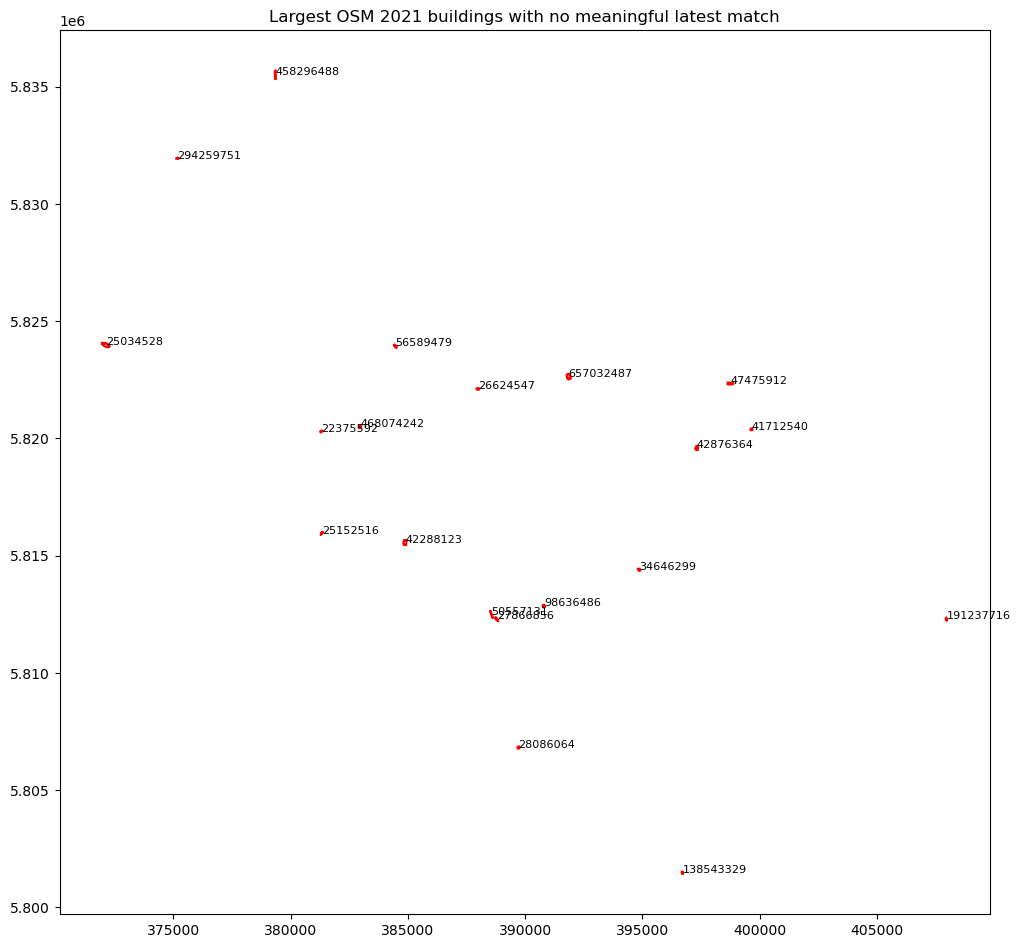

In [124]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 12))

largest_disappearance_candidates.plot(
    ax=ax,
    facecolor="none",
    edgecolor="red",
    linewidth=1.5
)

for _, row in largest_disappearance_candidates.iterrows():
    centroid = row.geometry.centroid

    ax.annotate(
        str(row["osm_id_old"]),
        xy=(centroid.x, centroid.y),
        fontsize=8
    )

ax.set_title(
    "Largest OSM 2021 buildings with no meaningful latest match"
)

ax.set_aspect("equal")
plt.show()

In [127]:
import matplotlib.pyplot as plt

def plot_osm_candidate_zoom(
    osm_id,
    buffer_m=100,
    figsize=(8, 8)
):
    """
    Plot one OSM 2021 disappearance candidate with a highly
    zoomed-in view of its immediate surroundings.
    """

    old_row = disappearance_candidates[
        disappearance_candidates["osm_id_old"] == osm_id
    ]

    if old_row.empty:
        print(f"OSM ID {osm_id} not found.")
        return

    old_geom = old_row.geometry.iloc[0]

    # Local bounding box with buffer
    minx, miny, maxx, maxy = old_geom.bounds

    minx -= buffer_m
    miny -= buffer_m
    maxx += buffer_m
    maxy += buffer_m

    # Select latest buildings intersecting the local view
    latest_local = osm_latest_m.cx[
        minx:maxx,
        miny:maxy
    ].copy()

    fig, ax = plt.subplots(figsize=figsize)

    # Latest geometries
    latest_local.plot(
        ax=ax,
        facecolor="lightgrey",
        edgecolor="steelblue",
        linewidth=1,
        alpha=0.8
    )

    # Old candidate
    old_row.plot(
        ax=ax,
        facecolor="none",
        edgecolor="red",
        linewidth=2.5
    )

    # Candidate centroid and label
    centroid = old_geom.centroid

    ax.annotate(
        f"OSM 2021 ID: {osm_id}",
        xy=(centroid.x, centroid.y),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=10,
        color="red",
        weight="bold"
    )

    ax.set_xlim(minx, maxx)
    ax.set_ylim(miny, maxy)

    ax.set_title(
        f"OSM temporal inspection — candidate {osm_id}\n"
        f"Old area: {old_row['old_area_m2'].iloc[0]:,.1f} m²"
    )

    ax.set_aspect("equal")
    plt.tight_layout()
    plt.show()

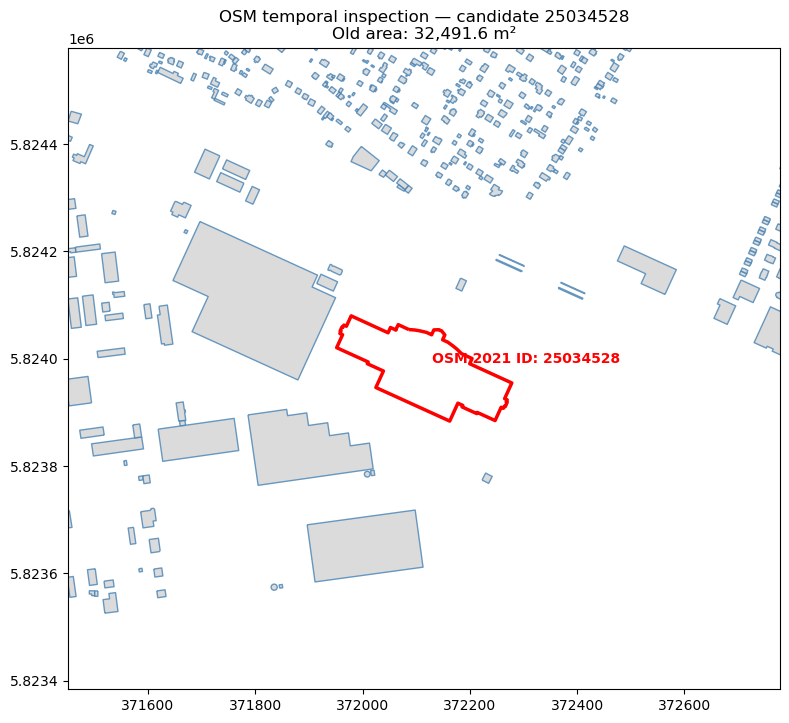

In [130]:
plot_osm_candidate_zoom(
    osm_id=largest_disappearance_candidates.iloc[0]["osm_id_old"],
    buffer_m=500
)

Inspecting OSM ID: 25034528


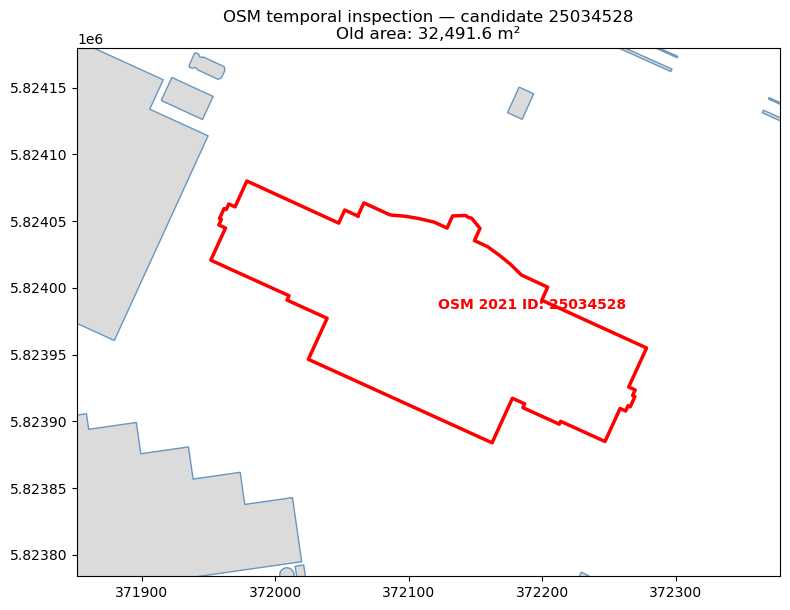

Inspecting OSM ID: 42288123


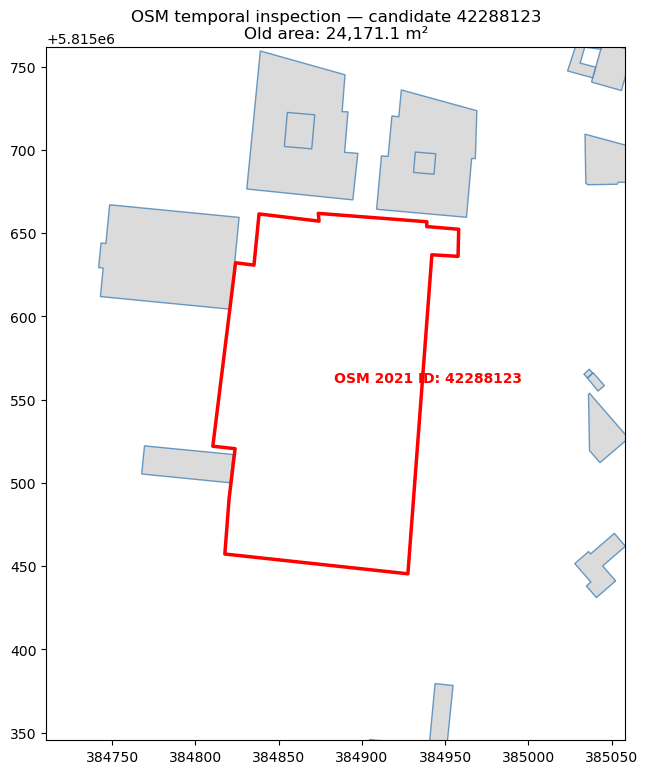

Inspecting OSM ID: 47475912


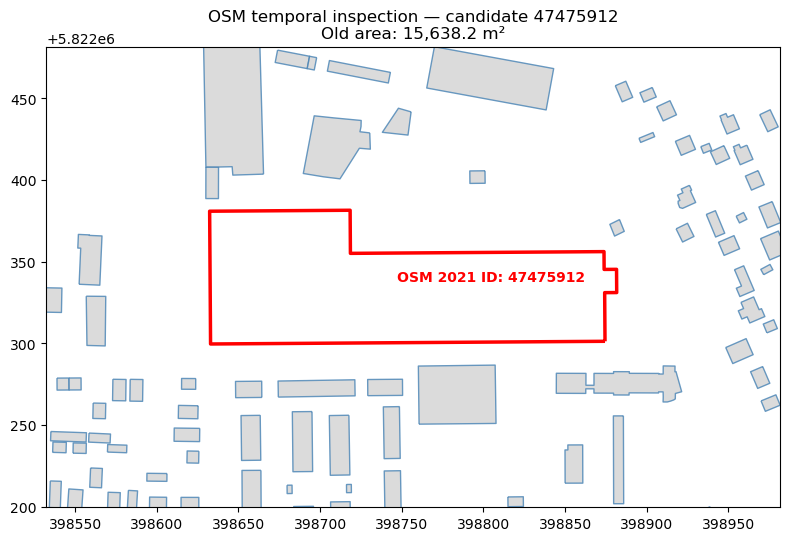

Inspecting OSM ID: 458296488


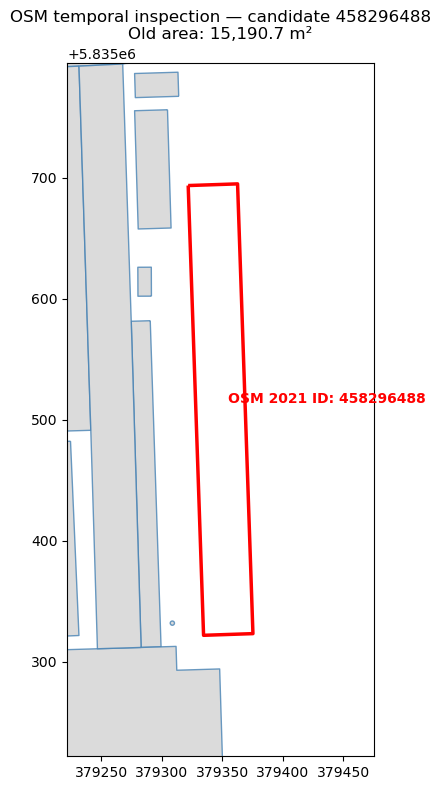

Inspecting OSM ID: 27866856


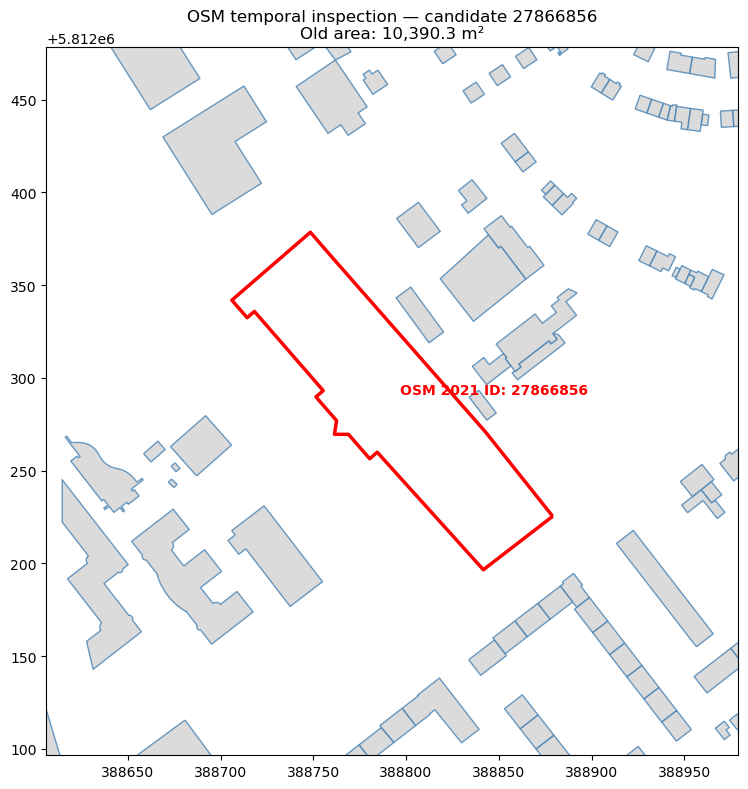

In [131]:
for osm_id in largest_disappearance_candidates["osm_id_old"].head(5):
    print(f"Inspecting OSM ID: {osm_id}")
    plot_osm_candidate_zoom(
        osm_id=osm_id,
        buffer_m=100
    )

In [132]:
# Inspect tags from a few OSM 2021 records
display(
    osm_2021_m[["osm_id", "tags"]].head(10)
)

,osm_id,tags
0,200902863,"[(building, yes)]"
1,200902893,"[(source, Geoportal Berlin / Hausumringe), (bu..."
2,271261713,"[(source, Geoportal Berlin / Hausumringe), (bu..."
3,200902913,"[(source, Geoportal Berlin / Hausumringe), (bu..."
4,271351155,"[(source, Geoportal Berlin / Hausumringe), (bu..."
5,200906474,"[(source, Geoportal Berlin / Hausumringe), (bu..."
6,310667703,"[(building, yes)]"
7,176922593,"[(building, yes)]"
8,311186214,"[(building, yes)]"
9,103456881,"[(building, industrial), (addr:city, Berlin), ..."


In [133]:
sample_tags = osm_2021_m["tags"].dropna().iloc[0]

print(type(sample_tags))
print(sample_tags)

<class 'list'>
[('building', 'yes')]


In [134]:
disappearance_candidates["centroid"] = (
    disappearance_candidates.geometry.centroid
)

disappearance_candidates["x"] = (
    disappearance_candidates.centroid.x
)

disappearance_candidates["y"] = (
    disappearance_candidates.centroid.y
)

candidate_locations = (
    disappearance_candidates
    .sort_values("old_area_m2", ascending=False)
    .head(20)
    [
        [
            "osm_id_old",
            "old_area_m2",
            "x",
            "y"
        ]
    ]
)

display(candidate_locations)

,osm_id_old,old_area_m2,x,y
2621,25034528,32491.603374,372116.793851,5.823979e+06
1457,42288123,24171.068902,384879.326488,5.815556e+06
6885,47475912,15638.153531,398742.961531,5.822334e+06
4427,458296488,15190.674861,379348.467801,5.835508e+06
882,27866856,10390.321979,388793.263662,5.812287e+06
3716,657032487,9820.300814,391840.601607,5.822627e+06
3495,468074242,9765.727262,382967.142694,5.820498e+06
645,50557131,9117.951608,388565.870804,5.812492e+06
749,98636486,8903.045985,390799.426248,5.812845e+06
4376,56589479,7726.311324,384473.956947,5.823929e+06


In [135]:
candidate_points = gpd.GeoDataFrame(
    candidate_locations.copy(),
    geometry=gpd.points_from_xy(
        candidate_locations["x"],
        candidate_locations["y"]
    ),
    crs="EPSG:25833"
).to_crs("EPSG:4326")

candidate_points["lon"] = candidate_points.geometry.x
candidate_points["lat"] = candidate_points.geometry.y

display(
    candidate_points[
        ["osm_id_old", "old_area_m2", "lon", "lat"]
    ]
)

,osm_id_old,old_area_m2,lon,lat
2621,25034528,32491.603374,13.113860,52.550847
1457,42288123,24171.068902,13.304915,52.478006
6885,47475912,15638.153531,13.506905,52.541664
4427,458296488,15190.674861,13.216257,52.656096
882,27866856,10390.321979,13.363609,52.449440
3716,657032487,9820.300814,13.405072,52.542974
3495,468074242,9765.727262,13.275035,52.522004
645,50557131,9117.951608,13.360196,52.451230
749,98636486,8903.045985,13.392934,52.454858
4376,56589479,7726.311324,13.296040,52.553160


In [138]:
osm_temporal_register = all_old_register.copy()

osm_temporal_register.shape

(632361, 11)

In [139]:
osm_temporal_register.to_parquet(
    "osm_temporal_change_register_2021_latest.parquet",
    index=False
)

In [140]:
osm_2021_m[
    ["osm_id", "geometry"]
].to_file(
    "osm_2021_reference_buildings.gpkg",
    layer="osm_2021_buildings",
    driver="GPKG"
)

In [146]:
from pathlib import Path

OUTPUT_DIR = Path("osm_temporal_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

OUTPUT_DIR

WindowsPath('osm_temporal_outputs')

In [147]:
osm_temporal_register = all_old_register.copy()

print("Shape:", osm_temporal_register.shape)
print("\nColumns:")
print(osm_temporal_register.columns.tolist())

osm_temporal_register.head()

Shape: (632361, 11)

Columns:
['osm_id_old', 'old_area_m2', 'n_latest_matches', 'total_intersection_area_m2', 'max_overlap_old', 'max_overlap_new', 'total_overlap_old', 'coverage_old', 'match_status', 'temporal_class', 'candidate_group']


,osm_id_old,old_area_m2,n_latest_matches,total_intersection_area_m2,max_overlap_old,max_overlap_new,total_overlap_old,coverage_old,match_status,temporal_class,candidate_group
0,200902863,79.804382,1,79.804382,1.0,1.0,1.0,1.0,one_to_one,strong_geometric_persistence,persistent_building
1,200902893,118.886808,1,118.886808,1.0,1.0,1.0,1.0,one_to_one,strong_geometric_persistence,persistent_building
2,271261713,30.412556,1,30.412556,1.0,1.0,1.0,1.0,one_to_one,strong_geometric_persistence,persistent_building
3,200902913,93.287418,1,93.287418,1.0,1.0,1.0,1.0,one_to_one,strong_geometric_persistence,persistent_building
4,271351155,24.428677,1,24.428677,1.0,1.0,1.0,1.0,one_to_one,strong_geometric_persistence,persistent_building


In [148]:
csv_path = OUTPUT_DIR / "osm_temporal_change_register_2021_latest.csv"

osm_temporal_register.to_csv(
    csv_path,
    index=False
)

print(f"Saved CSV: {csv_path}")

Saved CSV: osm_temporal_outputs\osm_temporal_change_register_2021_latest.csv


In [149]:
osm_temporal_register = all_old_register.copy()

print("Shape:", osm_temporal_register.shape)
print("\nColumns:")
print(osm_temporal_register.columns.tolist())

osm_temporal_register.head()

Shape: (632361, 11)

Columns:
['osm_id_old', 'old_area_m2', 'n_latest_matches', 'total_intersection_area_m2', 'max_overlap_old', 'max_overlap_new', 'total_overlap_old', 'coverage_old', 'match_status', 'temporal_class', 'candidate_group']


,osm_id_old,old_area_m2,n_latest_matches,total_intersection_area_m2,max_overlap_old,max_overlap_new,total_overlap_old,coverage_old,match_status,temporal_class,candidate_group
0,200902863,79.804382,1,79.804382,1.0,1.0,1.0,1.0,one_to_one,strong_geometric_persistence,persistent_building
1,200902893,118.886808,1,118.886808,1.0,1.0,1.0,1.0,one_to_one,strong_geometric_persistence,persistent_building
2,271261713,30.412556,1,30.412556,1.0,1.0,1.0,1.0,one_to_one,strong_geometric_persistence,persistent_building
3,200902913,93.287418,1,93.287418,1.0,1.0,1.0,1.0,one_to_one,strong_geometric_persistence,persistent_building
4,271351155,24.428677,1,24.428677,1.0,1.0,1.0,1.0,one_to_one,strong_geometric_persistence,persistent_building


In [150]:
osm_temporal_gdf = osm_2021_m[
    ["osm_id", "geometry"]
].rename(
    columns={"osm_id": "osm_id_old"}
).merge(
    osm_temporal_register,
    on="osm_id_old",
    how="right"
)

osm_temporal_gdf = gpd.GeoDataFrame(
    osm_temporal_gdf,
    geometry="geometry",
    crs=osm_2021_m.crs
)

print("Spatial register shape:", osm_temporal_gdf.shape)
print("CRS:", osm_temporal_gdf.crs)
osm_temporal_gdf.head()

Spatial register shape: (632361, 12)
CRS: EPSG:25833


,osm_id_old,geometry,old_area_m2,n_latest_matches,total_intersection_area_m2,max_overlap_old,max_overlap_new,total_overlap_old,coverage_old,match_status,temporal_class,candidate_group
0,200902863,"POLYGON ((392071.791 5810757.515, 392082.575 5...",79.804382,1,79.804382,1.0,1.0,1.0,1.0,one_to_one,strong_geometric_persistence,persistent_building
1,200902893,"POLYGON ((392030.27 5810755.501, 392045.818 58...",118.886808,1,118.886808,1.0,1.0,1.0,1.0,one_to_one,strong_geometric_persistence,persistent_building
2,271261713,"POLYGON ((392035.449 5810884.387, 392034.897 5...",30.412556,1,30.412556,1.0,1.0,1.0,1.0,one_to_one,strong_geometric_persistence,persistent_building
3,200902913,"POLYGON ((392005.194 5810576.345, 392012.471 5...",93.287418,1,93.287418,1.0,1.0,1.0,1.0,one_to_one,strong_geometric_persistence,persistent_building
4,271351155,"POLYGON ((392028.129 5810656.236, 392025.488 5...",24.428677,1,24.428677,1.0,1.0,1.0,1.0,one_to_one,strong_geometric_persistence,persistent_building


In [151]:
gpkg_path = OUTPUT_DIR / "osm_temporal_change_register_2021_latest.gpkg"

osm_temporal_gdf.to_file(
    gpkg_path,
    layer="osm_temporal_register",
    driver="GPKG"
)

print(f"Saved GeoPackage: {gpkg_path}")

Saved GeoPackage: osm_temporal_outputs\osm_temporal_change_register_2021_latest.gpkg


In [152]:
disappearance_candidates = osm_temporal_gdf[
    osm_temporal_gdf["candidate_group"] == "disappearance_or_no_match_candidate"
].copy()

geometry_change_candidates = osm_temporal_gdf[
    osm_temporal_gdf["candidate_group"] == "geometry_change_candidate"
].copy()

print("Disappearance candidates:", len(disappearance_candidates))
print("Geometry-change candidates:", len(geometry_change_candidates))

Disappearance candidates: 9156
Geometry-change candidates: 4080


In [153]:
disappearance_candidates.to_file(
    gpkg_path,
    layer="disappearance_candidates",
    driver="GPKG"
)

geometry_change_candidates.to_file(
    gpkg_path,
    layer="geometry_change_candidates",
    driver="GPKG"
)

print("Candidate layers saved.")

Candidate layers saved.


In [154]:
from pathlib import Path

print("Current working directory:")
print(Path.cwd())

print("\nOutput directory:")
print(OUTPUT_DIR.resolve())

print("\nFiles saved:")
for f in OUTPUT_DIR.resolve().iterdir():
    print(f)

Current working directory:
C:\Users\deqin

Output directory:
C:\Users\deqin\osm_temporal_outputs

Files saved:
C:\Users\deqin\osm_temporal_outputs\osm_temporal_change_register_2021_latest.csv
C:\Users\deqin\osm_temporal_outputs\osm_temporal_change_register_2021_latest.gpkg
